<a href="https://colab.research.google.com/github/Glaze0/Assignment/blob/main/Complete_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Media Company Case Study

## Multiple Linear Regression

### Problem Statement:
A digital media company (similar to Voot, Hotstar, Netflix, etc.) had launched a show. Initially, the show got a good response, but then witnessed a decline in viewership. The company wants to figure out what went wrong.


### Approach:
We are concerned about determining the driver variable for show viewership. This is the case of prediction rather than projection where we are more interested in predicting the key driver variables and their impact rather than forcasting the results.

First we will list down the potential reasons for the decline in viewershp.<br>

The potential reasons could be:
1. Decline in the number of people coming to the platform
2. Fewer people watching the video
3. A Decrease in marketing spend?
4. Competitive shows, e.g. cricket/ IPL
5. Special holidays
6. Twist in the story


### Data
We have been given data for the period of 1 March 2017 to 19 May 2017.<br>
With Columns as<br>
Views_show         : Number of times the show was viewed<br>
Visitors           : Number of visitors who browsed the platform, but not necessarily watched a video.<br>
Views_platform	   : Number of times a video was viewed on the platform<br>
Ad_impression	   : Proxy for marketing budget. Represents number of impressions generated by ads<br>
Cricket_match_india: If a cricket match was being played. 1 indicates match on a given day, 0 indicates there wasn't<br>
Character_A        : Describes presence of Character A. 1 indicates character A was in the episode, 0 indicates she/he wasn't

In [ ]:
# 1 : Data loading, inspection & cleaning
# 2 : EDA

In [ ]:
# Importing base libraries
import numpy as np
import pandas as pd

# Importing data viz libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Supresses warnings
import warnings
warnings.filterwarnings('ignore')

# Machine Learnign Library
import statsmodels.api as sm #

In [ ]:
media = pd.read_csv("mediacompany.csv")
del media['Unnamed: 7']
media.head()

,Date,Views_show,Visitors,Views_platform,Ad_impression,Cricket_match_india,Character_A
0,3/1/2017,183738,1260228,1706478,1060860448,0,0
1,3/2/2017,193763,1270561,1690727,1031846645,0,0
2,3/3/2017,210479,1248183,1726157,1010867575,0,0
3,3/4/2017,240061,1492913,1855353,1079194579,1,0
4,3/5/2017,446314,1594712,2041418,1357736987,0,0


In [ ]:
media.tail()

,Date,Views_show,Visitors,Views_platform,Ad_impression,Cricket_match_india,Character_A
75,5/15/2017,313945,1808684,2226788,1398052759,1,0
76,5/16/2017,185689,1814227,2199844,1311961223,1,0
77,5/17/2017,142260,1755803,2225752,1248266254,1,0
78,5/18/2017,135871,1749654,2302789,1284859759,1,0
79,5/19/2017,108961,1746735,2279036,1246026846,1,0


# Data inspection

In [ ]:
media.shape

(80, 7)

In [ ]:
media.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Date                 80 non-null     object
 1   Views_show           80 non-null     int64 
 2   Visitors             80 non-null     int64 
 3   Views_platform       80 non-null     int64 
 4   Ad_impression        80 non-null     int64 
 5   Cricket_match_india  80 non-null     int64 
 6   Character_A          80 non-null     int64 
dtypes: int64(6), object(1)
memory usage: 4.5+ KB


In [ ]:
media.head()

,Date,Views_show,Visitors,Views_platform,Ad_impression,Cricket_match_india,Character_A
0,3/1/2017,183738,1260228,1706478,1060860448,0,0
1,3/2/2017,193763,1270561,1690727,1031846645,0,0
2,3/3/2017,210479,1248183,1726157,1010867575,0,0
3,3/4/2017,240061,1492913,1855353,1079194579,1,0
4,3/5/2017,446314,1594712,2041418,1357736987,0,0


In [ ]:
media[['Views_show','Visitors',
       'Views_platform','Ad_impression']].describe()

,Views_show,Visitors,Views_platform,Ad_impression
count,80.000000,8.000000e+01,8.000000e+01,8.000000e+01
mean,289902.625000,1.699066e+06,2.222401e+06,1.442374e+09
std,154924.323585,2.311571e+05,2.913510e+05,2.983186e+08
min,102520.000000,1.248183e+06,1.690727e+06,1.010868e+09
25%,185353.250000,1.550766e+06,2.010816e+06,1.207911e+09
50%,235807.000000,1.698843e+06,2.226270e+06,1.385931e+09
75%,350079.000000,1.817895e+06,2.388837e+06,1.632416e+09
max,758631.000000,2.344650e+06,3.064422e+06,2.424203e+09


# Data inspection

In [ ]:
media.isnull().sum()

,0
Date,0
Views_show,0
Visitors,0
Views_platform,0
Ad_impression,0
Cricket_match_india,0
Character_A,0


In [ ]:
media.dtypes

,0
Date,object
Views_show,int64
Visitors,int64
Views_platform,int64
Ad_impression,int64
Cricket_match_india,int64
Character_A,int64


In [ ]:
media.Date = pd.to_datetime(media.Date)

In [ ]:
media.dtypes

,0
Date,datetime64[ns]
Views_show,int64
Visitors,int64
Views_platform,int64
Ad_impression,int64
Cricket_match_india,int64
Character_A,int64


In [ ]:
media['Day_of_week'] = media.Date.dt.dayofweek
media['Day_of_week'].value_counts() #1 - Sunday!

,count
Day_of_week,
2,12
3,12
4,12
5,11
6,11
0,11
1,11


In [ ]:
# Exploratory Data Analysis

In [ ]:
media.head()

,Date,Views_show,Visitors,Views_platform,Ad_impression,Cricket_match_india,Character_A,Day_of_week
0,2017-03-01,183738,1260228,1706478,1060860448,0,0,2
1,2017-03-02,193763,1270561,1690727,1031846645,0,0,3
2,2017-03-03,210479,1248183,1726157,1010867575,0,0,4
3,2017-03-04,240061,1492913,1855353,1079194579,1,0,5
4,2017-03-05,446314,1594712,2041418,1357736987,0,0,6


<Axes: xlabel='Date'>

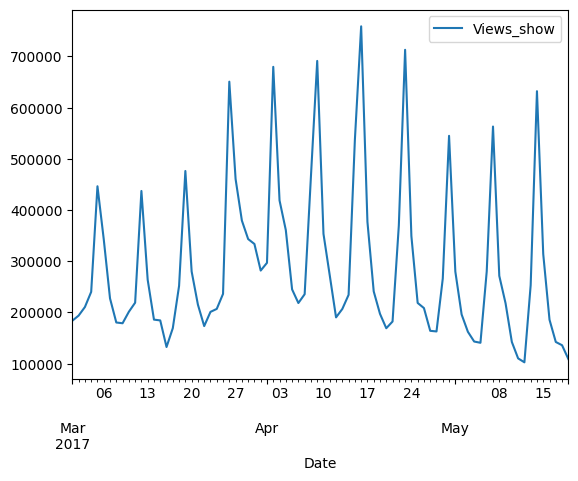

In [ ]:
# Views_show - analyse the trend over time?
media.plot.line(x='Date',y='Views_show')

In [ ]:
# inference : there's a repeating patterns --> inc,dec,inc,dec

In [ ]:
# Views_show on each Day_of_week

<Axes: xlabel='Day_of_week', ylabel='Views_show'>

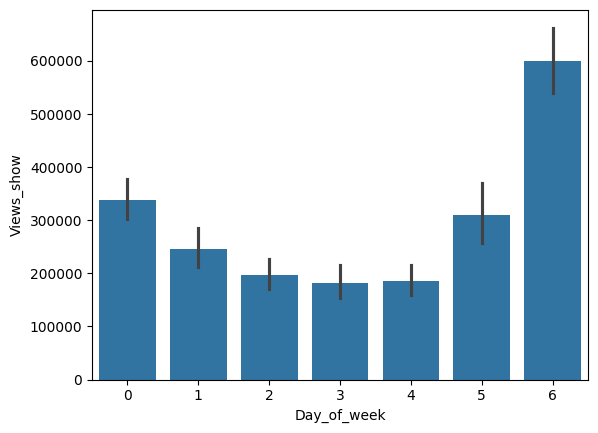

In [ ]:
sns.barplot(data=media,x = 'Day_of_week',y = 'Views_show')

In [ ]:
# weekend I have more views than weekdays!

In [ ]:
media['weekend'] = media.Day_of_week.map({5:1,6:1,0:0, 1:0, 2:0, 3:0, 4:0})

In [ ]:
media.weekend

,weekend
0,0
1,0
2,0
3,1
4,1
...,...
75,0
76,0
77,0
78,0


In [ ]:
media.head()

,Date,Views_show,Visitors,Views_platform,Ad_impression,Cricket_match_india,Character_A,Day_of_week,weekend
0,2017-03-01,183738,1260228,1706478,1060860448,0,0,2,0
1,2017-03-02,193763,1270561,1690727,1031846645,0,0,3,0
2,2017-03-03,210479,1248183,1726157,1010867575,0,0,4,0
3,2017-03-04,240061,1492913,1855353,1079194579,1,0,5,1
4,2017-03-05,446314,1594712,2041418,1357736987,0,0,6,1


<Axes: xlabel='weekend', ylabel='Views_show'>

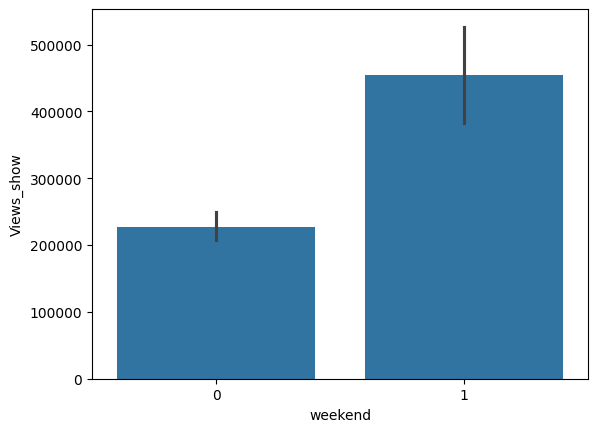

In [ ]:
sns.barplot(data=media,x = 'weekend',y = 'Views_show')

In [ ]:
media.columns

Index(['Date', 'Views_show', 'Visitors', 'Views_platform', 'Ad_impression',
       'Cricket_match_india', 'Character_A', 'Day_of_week', 'weekend'],
      dtype='object')

<Axes: xlabel='Visitors', ylabel='Views_show'>

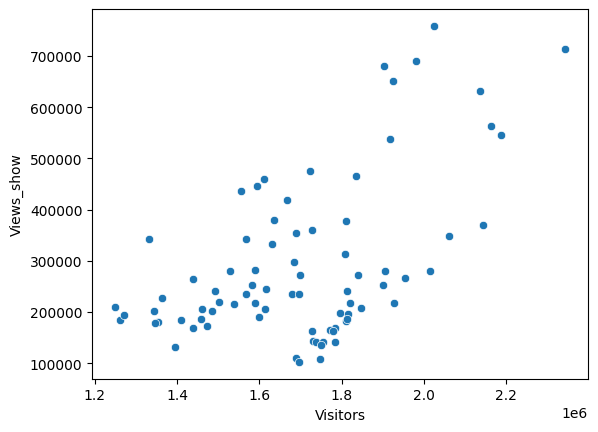

In [ ]:
# 1) 'Views_show', 'Visitors'
sns.scatterplot(data=media,x = "Visitors",y= "Views_show")

<Axes: xlabel='Ad_impression', ylabel='Views_show'>

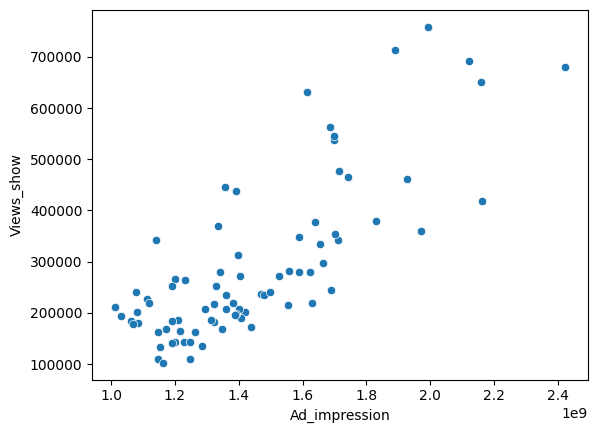

In [ ]:
# 2)'Views_show','Ad_impression'
sns.scatterplot(data=media,x = "Ad_impression",y= "Views_show")

<Axes: xlabel='Views_platform', ylabel='Views_show'>

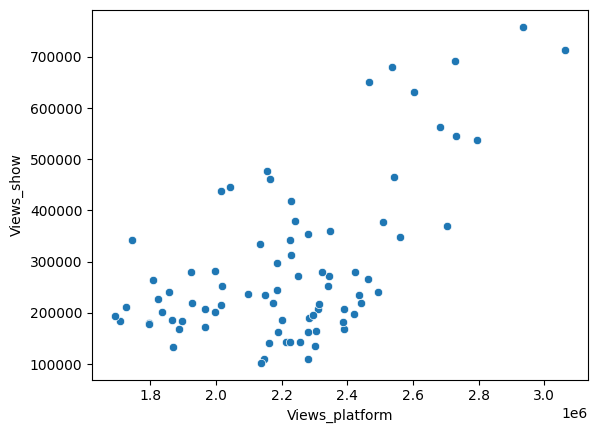

In [ ]:
# 3)'Views_platform','Views_show'
sns.scatterplot(data=media,x = "Views_platform",y= "Views_show")

In [ ]:
media.head()

,Date,Views_show,Visitors,Views_platform,Ad_impression,Cricket_match_india,Character_A,Day_of_week,weekend
0,2017-03-01,183738,1260228,1706478,1060860448,0,0,2,0
1,2017-03-02,193763,1270561,1690727,1031846645,0,0,3,0
2,2017-03-03,210479,1248183,1726157,1010867575,0,0,4,0
3,2017-03-04,240061,1492913,1855353,1079194579,1,0,5,1
4,2017-03-05,446314,1594712,2041418,1357736987,0,0,6,1


<Axes: xlabel='Cricket_match_india', ylabel='Views_show'>

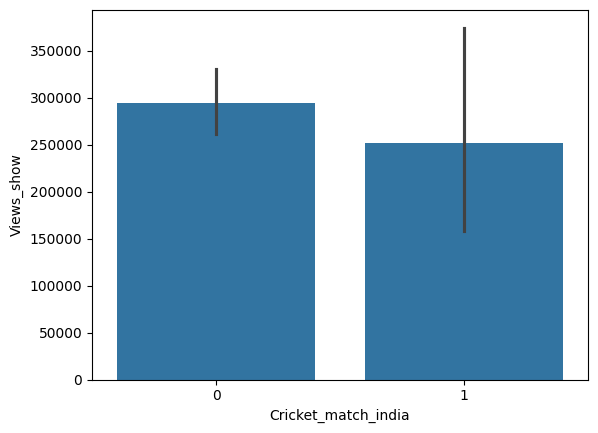

In [ ]:
# 4) 'Views_show', 'Cricket_match_india'
sns.barplot(data=media,x='Cricket_match_india',y='Views_show')

<Axes: xlabel='Character_A', ylabel='Views_show'>

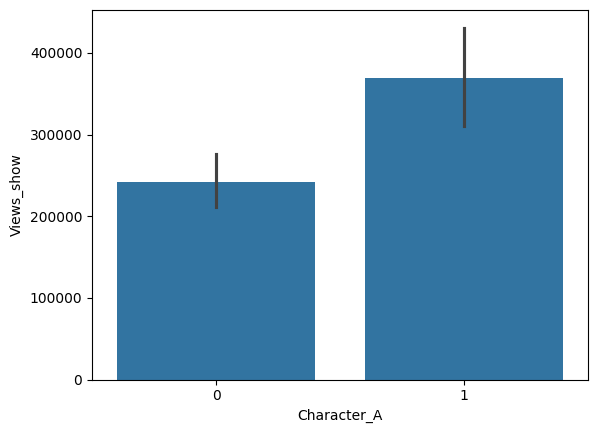

In [ ]:
# 5) 'Views_show', 'Character_A'
sns.barplot(data=media,x='Character_A',y='Views_show')

<Axes: >

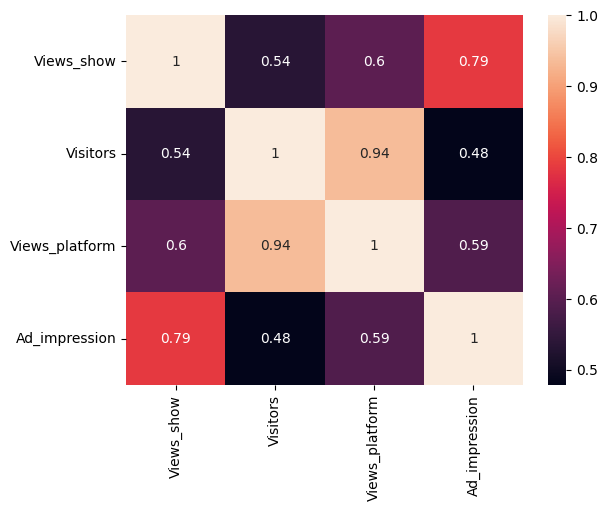

In [ ]:
# 6) Correlation Matrix for all numerical columns
sns.heatmap(media[['Views_show','Visitors',
                   'Views_platform','Ad_impression']].corr(),annot=True)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

In [ ]:
X = media[['Visitors', 'Views_platform', 'Ad_impression',
           'Cricket_match_india', 'Character_A', 'Day_of_week', 'weekend']]

y = media['Views_show']

In [ ]:
# -----------------------------
# Train-Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# -----------------------------
# Models
# -----------------------------
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42)
}

# -----------------------------
# Train & Evaluate
# -----------------------------
results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100

    results.append({
        "Model": name,
        "R²": round(r2, 4),
        "MAE": round(mae, 2),
        "MSE": round(mse, 2),
        "RMSE": round(rmse, 2),
        "MAPE (%)": round(mape, 2)
    })

# -----------------------------
# Results Table
# -----------------------------
results_df = pd.DataFrame(results)

results_df = results_df.sort_values("R²", ascending=False)

display(results_df)

,Model,R²,MAE,MSE,RMSE,MAPE (%)
2,Random Forest,0.8568,35726.77,2.321715e+09,48184.18,12.10
0,Linear Regression,0.7144,59829.63,4.631042e+09,68051.76,21.74
3,XGBoost,0.6693,52748.09,5.363242e+09,73234.16,15.37
1,Decision Tree,0.6506,54769.50,5.665862e+09,75271.92,19.00


In [ ]:
# Task 1 :
# a. Run Linear Regression using statsmodelsapi
# b. add constant in x
# c. fit
# d. print summary
# Output : Rsquare and which variables are insignificant in NATURE!

In [ ]:
X = sm.add_constant(X)

lr = sm.OLS(y,X).fit() # this is your linear regression algo!

print(lr.summary())

In [ ]:
# Removed Cricket Match India

X = media[['Visitors', 'Views_platform', 'Ad_impression', 'Character_A', 'Day_of_week', 'weekend']]

y = media['Views_show']

X = sm.add_constant(X)

lr = sm.OLS(y,X).fit() # this is your linear regression algo!

print(lr.summary())

In [ ]:
# Removed Day_of_week

X = media[['Visitors', 'Views_platform', 'Ad_impression', 'Character_A', 'weekend']]

y = media['Views_show']

X = sm.add_constant(X)

lr = sm.OLS(y,X).fit() # this is your linear regression algo!

print(lr.summary())

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, root_mean_squared_error

In [ ]:
# X = media[['Views_platform', 'Ad_impression', 'Character_A', 'weekend']]
X = media[['Views_platform', 'Ad_impression',  'weekend']]
y = media['Views_show']
X_train, X_test, y_train, y_test = train_test_split(X,y,
                                                    test_size=0.3,random_state=42)

In [ ]:
from sklearn.tree import DecisionTreeRegressor
dt_sk = DecisionTreeRegressor()
dt_sk.fit(X_train,y_train) # DT Regression model
y_pred_dt = dt_sk.predict(X_test)

In [ ]:
print("r2_score : ", r2_score(y_test,y_pred_dt))
print("mean_squared_error : ", mean_squared_error(y_test,y_pred_dt))
print("mean_absolute_error : ", mean_absolute_error(y_test,y_pred_dt))
print("root_mean_squared_error : ", root_mean_squared_error(y_test,y_pred_dt))
print("mean_abs_%_error : ", mean_absolute_percentage_error(y_test,y_pred_dt))

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 10))
plot_tree(dt_sk, filled=True,
          rounded=True,
          fontsize=10,
          feature_names=X.columns,
          max_depth = 3)
plt.show()

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": dt_sk.feature_importances_
})

feature_importance.sort_values("Importance", ascending=False)

In [ ]:
# max depth = 2
from sklearn.tree import DecisionTreeRegressor
dt_sk = DecisionTreeRegressor(max_depth=2)
dt_sk.fit(X_train,y_train) # DT Regression model
y_pred_dt = dt_sk.predict(X_test)
print("r2_score : ", r2_score(y_test,y_pred_dt))
print("mean_squared_error : ", mean_squared_error(y_test,y_pred_dt))
print("mean_absolute_error : ", mean_absolute_error(y_test,y_pred_dt))
print("root_mean_squared_error : ", root_mean_squared_error(y_test,y_pred_dt))
print("mean_abs_%_error : ", mean_absolute_percentage_error(y_test,y_pred_dt))

In [ ]:
# max depth = 20
from sklearn.tree import DecisionTreeRegressor
dt_sk = DecisionTreeRegressor(max_depth=20)
dt_sk.fit(X_train,y_train) # DT Regression model
y_pred_dt = dt_sk.predict(X_test)
print("r2_score : ", r2_score(y_test,y_pred_dt))
print("mean_squared_error : ", mean_squared_error(y_test,y_pred_dt))
print("mean_absolute_error : ", mean_absolute_error(y_test,y_pred_dt))
print("root_mean_squared_error : ", root_mean_squared_error(y_test,y_pred_dt))
print("mean_abs_%_error : ", mean_absolute_percentage_error(y_test,y_pred_dt))

In [ ]:
lr_sk = LinearRegression()
lr_sk.fit(X_train,y_train) # Linear Regression model

In [ ]:
# y_train_pred = lr_sk.predict(X_train)
y_pred = lr_sk.predict(X_test)

In [ ]:
y_test[:5]

In [ ]:
y_pred[:5]

In [ ]:
print("r2_score : ", r2_score(y_test,y_pred))
print("mean_squared_error : ", mean_squared_error(y_test,y_pred))
print("mean_absolute_error : ", mean_absolute_error(y_test,y_pred))
print("root_mean_squared_error : ", root_mean_squared_error(y_test,y_pred))
print("mean_abs_%_error : ", mean_absolute_percentage_error(y_test,y_pred))

In [ ]:
# print("r2_score : ", r2_score(y_train,y_train_pred))
# print("mean_squared_error : ", mean_squared_error(y_train,y_train_pred))
# print("mean_absolute_error : ", mean_absolute_error(y_train,y_train_pred))
# print("root_mean_squared_error : ", root_mean_squared_error(y_train,y_train_pred))
# print("mean_abs_%_error : ", mean_absolute_percentage_error(y_train,y_train_pred))

In [ ]:
# Run RandomForestRegressor and XGBoostRegressor
# Calc Rsq, MAE, MSE RMSE, MAPE
# Compae the results with Linear Regression, Decision Tree!

In [ ]:
pip install xgboost

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor